# App-29 — Équilibrage de chaîne d'assemblage (SALBP)
## Statut, borne, provenance

> **Hommage à Ilias Kalalou et Kaelan Grall** — projet B1, EPITA SCIA 2026

Leur projet a réuni dans un même appareil **SALBP-1**, **SALBP-2**, CP-SAT, PuLP/CBC, l'heuristique historique **Ranked Positional Weight**, une variante multi-modèles, une exploration bi-objectif, 25 instances, 57 tests et une application Streamlit. Cette amplitude est le geste central que cette distillation prolonge.

CoursIA reconstruit ici de petites expériences indépendantes pour apprendre à lire ce que prouve réellement un solveur : une affectation, un statut, une borne, un gap, une identité d'instance et, seulement lorsque toutes les conditions sont réunies, un optimum ou un front certifié.

**Parcours (~70 min)** — modèle → trois solveurs → certificats → provenance → Pareto → MMALBP → exercices.


## 1. Préparer l'expérience

SALBP affecte des tâches reliées par des précédences à une suite de stations. Une même station exécute ses tâches séquentiellement ; la somme de leurs durées ne dépasse pas le temps de cycle.

- **SALBP-1** : temps de cycle fixé, minimiser le nombre de stations.
- **SALBP-2** : nombre de stations fixé, minimiser le temps de cycle.

Les données ci-dessous sont synthétiques, déterministes et propres à CoursIA. Aucun module étudiant n'est importé.


In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from hashlib import sha256
from pathlib import Path
import json, math, platform, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp
from ortools.sat.python import cp_model
import ortools

DATA_DIR = Path("data/app29-salbp-audit")
if not DATA_DIR.exists():
    DATA_DIR = Path("MyIA.AI.Notebooks/Search/Applications/Hybrid/data/app29-salbp-audit")
DATA_DIR.mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class SALBPInstance:
    name: str
    durations: tuple[int, ...]
    precedences: tuple[tuple[int, int], ...]
    cycle_time: int

    @property
    def tasks(self):
        return tuple(range(len(self.durations)))

@dataclass
class SolveReport:
    method: str
    status: str
    objective: float | None
    best_bound: float | None
    gap: float | None
    wall_time: float
    assignment: dict[int, int] | None
    valid: bool

STATUS_NAMES = {
    cp_model.OPTIMAL: "OPTIMAL", cp_model.FEASIBLE: "FEASIBLE",
    cp_model.INFEASIBLE: "INFEASIBLE", cp_model.MODEL_INVALID: "MODEL_INVALID",
    cp_model.UNKNOWN: "UNKNOWN",
}

def relative_gap(objective, bound):
    if objective is None or bound is None:
        return None
    return abs(objective - bound) / max(1.0, abs(objective))

print({"python": platform.python_version(), "ortools": ortools.__version__, "pulp": pulp.__version__})


{'python': '3.13.14', 'ortools': '9.15.6755', 'pulp': '3.3.1'}


### Interprétation

L'environnement et les versions sont affichés plutôt que supposés. `SolveReport` sépare volontairement l'incumbent (`objective`) de la meilleure borne : l'égalité des deux, accompagnée du statut `OPTIMAL`, forme un certificat plus fort qu'une simple affectation.


## 2. Valider hors du solveur

Un modèle peut être mal encodé tout en retournant `OPTIMAL`. Le validateur suivant ne consulte aucune variable interne : il recalcule couverture, précédences, charges et objectif depuis l'affectation sérialisée.


In [2]:
def validate_solution(instance, assignment, cycle_time=None, expected_stations=None):
    if assignment is None or set(assignment) != set(instance.tasks):
        return False, {"reason": "task_coverage"}
    if any(not isinstance(s, int) or s < 0 for s in assignment.values()):
        return False, {"reason": "station_index"}
    for i, j in instance.precedences:
        if assignment[i] > assignment[j]:
            return False, {"reason": "precedence", "edge": [i, j]}
    loads = {}
    for task, station in assignment.items():
        loads[station] = loads.get(station, 0) + instance.durations[task]
    limit = instance.cycle_time if cycle_time is None else cycle_time
    if max(loads.values(), default=0) > limit:
        return False, {"reason": "cycle", "loads": loads, "limit": limit}
    stations = max(assignment.values(), default=-1) + 1
    if expected_stations is not None and stations > expected_stations:
        return False, {"reason": "station_count", "stations": stations}
    return True, {"loads": loads, "stations": stations, "cycle": max(loads.values())}

def identity_key(instance):
    payload = {
        "n_tasks": len(instance.durations),
        "durations": list(instance.durations),
        "precedences": [list(e) for e in sorted(instance.precedences)],
        "cycle_time": instance.cycle_time,
    }
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return sha256(raw.encode()).hexdigest()

def lower_bounds(instance):
    load = math.ceil(sum(instance.durations) / instance.cycle_time)
    longest = max(instance.durations)
    return {"load_lb": load, "single_task_feasible": longest <= instance.cycle_time}

TOY = SALBPInstance("coursia-toy", (6, 4, 5, 3, 7, 4, 6, 5),
                    ((0,2),(0,3),(1,3),(2,4),(3,5),(4,6),(5,6),(6,7)), 14)
print(identity_key(TOY)[:16], lower_bounds(TOY))


11480c70a3adf3d4 {'load_lb': 3, 'single_task_feasible': True}


### Interprétation

La borne de charge vaut ⌈Σ durées / cycle⌉. Elle ignore les précédences : elle est sûre mais peut être faible. Le hash encode la structure complète ; deux instances portant le même nom ne deviennent donc pas automatiquement comparables.


## 3. SALBP-1 et SALBP-2 avec CP-SAT

La double représentation `x[i,s]` rend les capacités lisibles. L'indice de station d'une tâche est une combinaison linéaire des booléens ; une précédence `(i,j)` impose `station[i] ≤ station[j]`.


In [3]:
def solve_salbp1_cpsat(instance, time_limit=10.0):
    n = len(instance.tasks)
    model = cp_model.CpModel()
    x = {(i,s): model.new_bool_var(f"x_{i}_{s}") for i in instance.tasks for s in range(n)}
    used = [model.new_bool_var(f"used_{s}") for s in range(n)]
    station = {i: model.new_int_var(0, n-1, f"station_{i}") for i in instance.tasks}
    for i in instance.tasks:
        model.add_exactly_one(x[i,s] for s in range(n))
        model.add(station[i] == sum(s*x[i,s] for s in range(n)))
    for s in range(n):
        count = sum(x[i,s] for i in instance.tasks)
        model.add(count >= used[s])
        model.add(count <= n*used[s])
        model.add(sum(instance.durations[i]*x[i,s] for i in instance.tasks) <= instance.cycle_time)
        if s+1 < n: model.add(used[s] >= used[s+1])
    for i,j in instance.precedences: model.add(station[i] <= station[j])
    model.minimize(sum(used))
    solver = cp_model.CpSolver(); solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 1; solver.parameters.random_seed = 29
    t0=time.perf_counter(); status=solver.solve(model); wall=time.perf_counter()-t0
    name=STATUS_NAMES.get(status, "UNKNOWN")
    assignment = {i: int(solver.value(station[i])) for i in instance.tasks} if status in (cp_model.OPTIMAL,cp_model.FEASIBLE) else None
    obj=float(solver.objective_value) if assignment else None
    bound=float(solver.best_objective_bound) if assignment else None
    valid=validate_solution(instance, assignment)[0] if assignment else False
    return SolveReport("CP-SAT SALBP-1", name, obj, bound, relative_gap(obj,bound), wall, assignment, valid)

def solve_salbp2_cpsat(instance, n_stations, time_limit=10.0):
    model=cp_model.CpModel(); n=len(instance.tasks)
    x={(i,s): model.new_bool_var(f"x_{i}_{s}") for i in instance.tasks for s in range(n_stations)}
    station={i:model.new_int_var(0,n_stations-1,f"station_{i}") for i in instance.tasks}
    cycle=model.new_int_var(max(instance.durations),sum(instance.durations),"cycle")
    for i in instance.tasks:
        model.add_exactly_one(x[i,s] for s in range(n_stations))
        model.add(station[i] == sum(s*x[i,s] for s in range(n_stations)))
    for s in range(n_stations):
        model.add(sum(instance.durations[i]*x[i,s] for i in instance.tasks) <= cycle)
    for i,j in instance.precedences: model.add(station[i] <= station[j])
    model.minimize(cycle)
    solver=cp_model.CpSolver(); solver.parameters.max_time_in_seconds=time_limit
    solver.parameters.num_search_workers=1; solver.parameters.random_seed=29
    t0=time.perf_counter(); status=solver.solve(model); wall=time.perf_counter()-t0
    name=STATUS_NAMES.get(status,"UNKNOWN")
    assignment={i:int(solver.value(station[i])) for i in instance.tasks} if status in (cp_model.OPTIMAL,cp_model.FEASIBLE) else None
    obj=float(solver.objective_value) if assignment else None; bound=float(solver.best_objective_bound) if assignment else None
    valid=validate_solution(instance,assignment,cycle_time=math.ceil(obj),expected_stations=n_stations)[0] if assignment else False
    return SolveReport("CP-SAT SALBP-2",name,obj,bound,relative_gap(obj,bound),wall,assignment,valid)

cp1=solve_salbp1_cpsat(TOY)
cp2=solve_salbp2_cpsat(TOY, int(cp1.objective))
print(pd.DataFrame([{k:v for k,v in asdict(r).items() if k != "assignment"} for r in [cp1,cp2]]).to_string(index=False))
print(validate_solution(TOY, cp1.assignment))


        method  status  objective  best_bound  gap  wall_time  valid
CP-SAT SALBP-1 OPTIMAL        4.0         4.0  0.0   0.055174   True
CP-SAT SALBP-2 OPTIMAL       11.0        11.0  0.0   0.015831   True
(True, {'loads': {1: 14, 0: 4, 2: 11, 3: 11}, 'stations': 4, 'cycle': 14})


### Interprétation

SALBP-1 fixe le cycle et minimise les stations ; SALBP-2 fixe ce nombre de stations et minimise la charge maximale. Les deux affectations sont revérifiées indépendamment. Une ligne `FEASIBLE` resterait utilisable, mais elle ne permettrait pas d'écrire « optimum ».


## 4. Deuxième formulation exacte et baseline RPW

Le projet B1 avait la bonne intuition pédagogique : confronter deux modèles exacts à une heuristique de domaine. La formulation PuLP/CBC croise le petit optimum ; RPW priorise chaque tâche par sa durée plus celle de tous ses descendants.


In [4]:
def solve_salbp1_pulp(instance, time_limit=10.0):
    n=len(instance.tasks); prob=pulp.LpProblem("SALBP1",pulp.LpMinimize)
    x=pulp.LpVariable.dicts("x",(instance.tasks,range(n)),cat="Binary")
    used=pulp.LpVariable.dicts("used",range(n),cat="Binary")
    for i in instance.tasks: prob += pulp.lpSum(x[i][s] for s in range(n)) == 1
    for s in range(n):
        prob += pulp.lpSum(instance.durations[i]*x[i][s] for i in instance.tasks) <= instance.cycle_time
        for i in instance.tasks: prob += x[i][s] <= used[s]
        if s+1<n: prob += used[s] >= used[s+1]
    for i,j in instance.precedences:
        prob += pulp.lpSum(s*x[i][s] for s in range(n)) <= pulp.lpSum(s*x[j][s] for s in range(n))
    prob += pulp.lpSum(used[s] for s in range(n))
    t0=time.perf_counter(); prob.solve(pulp.PULP_CBC_CMD(msg=False,timeLimit=time_limit,threads=1)); wall=time.perf_counter()-t0
    raw=pulp.LpStatus[prob.status]; status={"Optimal":"OPTIMAL","Infeasible":"INFEASIBLE","Not Solved":"UNKNOWN"}.get(raw,raw.upper())
    assignment=None
    if status in ("OPTIMAL","FEASIBLE"):
        assignment={i:max(range(n),key=lambda s:pulp.value(x[i][s]) or 0) for i in instance.tasks}
    obj=float(pulp.value(prob.objective)) if assignment else None
    valid=validate_solution(instance,assignment)[0] if assignment else False
    return SolveReport("PuLP/CBC SALBP-1",status,obj,obj if status=="OPTIMAL" else None,0.0 if status=="OPTIMAL" else None,wall,assignment,valid)

def descendants(instance, root):
    succ={i:set() for i in instance.tasks}
    for a,b in instance.precedences: succ[a].add(b)
    seen=set(); stack=list(succ[root])
    while stack:
        u=stack.pop()
        if u not in seen: seen.add(u); stack.extend(succ[u])
    return seen

def rpw_weights(instance):
    return {i:instance.durations[i]+sum(instance.durations[j] for j in descendants(instance,i)) for i in instance.tasks}

def solve_rpw(instance):
    pred={i:set() for i in instance.tasks}
    for a,b in instance.precedences: pred[b].add(a)
    weights=rpw_weights(instance); remaining=set(instance.tasks); assignment={}; station=0; load=0
    while remaining:
        eligible=[i for i in remaining if pred[i] <= set(assignment)]
        fit=[i for i in eligible if load+instance.durations[i] <= instance.cycle_time]
        if not fit: station += 1; load=0; continue
        i=max(fit,key=lambda t:(weights[t],instance.durations[t],-t))
        assignment[i]=station; load += instance.durations[i]; remaining.remove(i)
    valid,details=validate_solution(instance,assignment)
    return SolveReport("RPW", "HEURISTIC", float(details["stations"]), None, None, 0.0, assignment, valid)

pulp1=solve_salbp1_pulp(TOY); rpw1=solve_rpw(TOY)
comparison=pd.DataFrame([{k:v for k,v in asdict(r).items() if k!="assignment"} for r in [cp1,pulp1,rpw1]])
print(comparison.to_string(index=False))


          method    status  objective  best_bound  gap  wall_time  valid
  CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   0.055174   True
PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   0.078715   True
             RPW HEURISTIC        4.0         NaN  NaN   0.000000   True


### Interprétation

Sur ce petit cas, les formulations exactes concordent et RPW construit une solution valide. Même si RPW atteint ici la même valeur, son statut reste `HEURISTIC` : l'égalité observée avec un optimum externe ne transforme pas sa procédure en preuve exacte.


## 5. Benchmark déterministe : statut, incumbent, borne, gap

Nous générons plusieurs DAG par couches. Les trois méthodes voient exactement le même hash d'instance et chaque affectation est validée hors modèle.


In [5]:
def generated_instance(seed, n=14, cycle=18):
    rng=np.random.default_rng(seed); durations=tuple(int(x) for x in rng.integers(2,9,size=n))
    layer=np.array_split(np.arange(n),4); edges=[]
    for a,b in zip(layer[:-1],layer[1:]):
        for j in b:
            candidates=[int(i) for i in a if rng.random()<0.55]
            if not candidates: candidates=[int(rng.choice(a))]
            edges.extend((i,int(j)) for i in candidates)
    return SALBPInstance(f"generated-{seed}",durations,tuple(sorted(set(edges))),cycle)

instances=[TOY]+[generated_instance(s) for s in (11,29,47,71)]
rows=[]
for inst in instances:
    for report in (solve_salbp1_cpsat(inst),solve_salbp1_pulp(inst),solve_rpw(inst)):
        rows.append({"instance":inst.name,"identity":identity_key(inst),**{k:v for k,v in asdict(report).items() if k!="assignment"}})
bench=pd.DataFrame(rows)
bench.to_csv(DATA_DIR/"benchmark_runs.csv",index=False)
print(bench[["instance","method","status","objective","best_bound","gap","valid"]].to_string(index=False))


    instance           method    status  objective  best_bound  gap  valid
 coursia-toy   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
 coursia-toy PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
 coursia-toy              RPW HEURISTIC        4.0         NaN  NaN   True
generated-11   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-11 PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-11              RPW HEURISTIC        4.0         NaN  NaN   True
generated-29   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-29 PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-29              RPW HEURISTIC        4.0         NaN  NaN   True
generated-47   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-47 PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-47              RPW HEURISTIC        4.0         NaN  NaN   True
generated-71   CP-SAT SAL

### Interprétation

Chaque ligne exacte publie simultanément statut, incumbent et borne. Les gaps nuls sont interprétables parce que les solveurs annoncent `OPTIMAL` et que les affectations passent le validateur. RPW sert de borne supérieure constructive, sans meilleure borne duale.


## 6. Une référence doit identifier l'instance

Deux tables peuvent légitimement utiliser le même nom pour des données différentes. Le contrat CoursIA refuse alors la jointure au lieu de fabriquer un écart à une « meilleure valeur connue ».


In [6]:
def join_bks(instance, reference):
    actual=identity_key(instance)
    if reference.get("identity") != actual:
        return {"status":"not_comparable","reason":"structural_identity_mismatch","reference":reference.get("value")}
    return {"status":"comparable","reference":reference["value"],"identity":actual}

accepted={"name":"coursia-toy","identity":identity_key(TOY),"value":int(cp1.objective)}
altered=SALBPInstance("coursia-toy",tuple(list(TOY.durations[:-1])+[6]),TOY.precedences,TOY.cycle_time)
refused={"name":"coursia-toy","identity":identity_key(altered),"value":2}
provenance={
    "generated_on":"2026-09-01","environment":{"python":platform.python_version(),"ortools":ortools.__version__,"pulp":pulp.__version__},
    "instances":[{"name":i.name,"identity":identity_key(i),"n_tasks":len(i.tasks),"durations":list(i.durations),"precedences":[list(e) for e in i.precedences],"cycle_time":i.cycle_time} for i in instances],
    "joins":{"accepted":join_bks(TOY,accepted),"refused":join_bks(TOY,refused)}
}
(DATA_DIR/"provenance.json").write_text(json.dumps(provenance,indent=2,ensure_ascii=False),encoding="utf-8")
print(json.dumps(provenance["joins"],indent=2,ensure_ascii=False))


{
  "accepted": {
    "status": "comparable",
    "reference": 4,
    "identity": "11480c70a3adf3d41ff8ab37bcda3860bf8bc8bf318cf841a508f5254035b972"
  },
  "refused": {
    "status": "not_comparable",
    "reason": "structural_identity_mismatch",
    "reference": 2
  }
}


### Interprétation

La première référence est comparable car son hash structurel correspond. La seconde porte le même nom, mais une durée diffère : `not_comparable` est le seul verdict honnête, et aucun pourcentage d'écart n'est calculé.


## 7. Front stations–cycle par ε-contrainte

Le balayage source était borné pour préserver l'interactivité. Ici, les instances restent petites : après avoir prouvé le minimum SALBP-1, nous résolvons SALBP-2 pour chaque nombre de stations jusqu'à la borne constructive RPW, puis éliminons strictement tout point dont le cycle ne s'améliore pas.


certified= True range= [4, 10]
 stations  objective  status  best_bound  valid
        4       13.0 OPTIMAL        13.0   True
        5       11.0 OPTIMAL        11.0   True
        6        9.0 OPTIMAL         9.0   True
        7        8.0 OPTIMAL         8.0   True


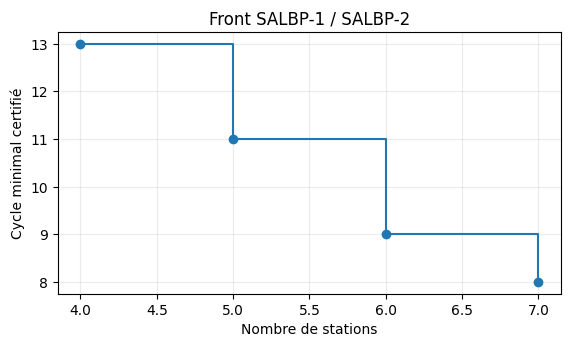

In [7]:
def strict_nondominated(reports):
    kept=[]; best_cycle=math.inf
    for stations,report in sorted(reports,key=lambda z:z[0]):
        if report.objective is not None and report.objective < best_cycle:
            kept.append((stations,report)); best_cycle=report.objective
    return kept

def pareto_front_complete(instance):
    salbp1=solve_salbp1_cpsat(instance); upper=int(solve_rpw(instance).objective)
    if salbp1.status!="OPTIMAL": return {"certified":False,"reason":"salbp1_not_optimal","points":[]}
    lower=int(salbp1.objective); upper=max(lower,upper)
    raw=[(m,solve_salbp2_cpsat(instance,m)) for m in range(lower,upper+1)]
    kept=strict_nondominated(raw)
    certified=all(r.status=="OPTIMAL" and r.valid for _,r in raw)
    return {"certified":certified,"range":[lower,upper],"points":[{"stations":m,**{k:v for k,v in asdict(r).items() if k!="assignment"}} for m,r in kept],"raw_status":[{"stations":m,"status":r.status,"valid":r.valid} for m,r in raw]}

# Une instance dédiée dont la borne RPW laisse plusieurs budgets de stations à auditer.
PARETO=SALBPInstance("pareto-line",(8,7,6,5,5,4,4,3,3,2),((0,3),(0,4),(1,4),(1,5),(2,5),(3,6),(4,6),(4,7),(5,7),(6,8),(7,8),(8,9)),14)
front=pareto_front_complete(PARETO)
# Si RPW est déjà optimal en stations, le nombre de tâches est une borne constructive triviale et sûre.
if front["range"][0]==front["range"][1]:
    raw=[(m,solve_salbp2_cpsat(PARETO,m)) for m in range(front["range"][0],len(PARETO.tasks)+1)]
    kept=strict_nondominated(raw)
    front={"certified":all(r.status=="OPTIMAL" and r.valid for _,r in raw),"range":[front["range"][0],len(PARETO.tasks)],"upper_bound":"one-task-per-station","points":[{"stations":m,**{k:v for k,v in asdict(r).items() if k!="assignment"}} for m,r in kept],"raw_status":[{"stations":m,"status":r.status,"valid":r.valid} for m,r in raw]}
(DATA_DIR/"pareto_fronts.json").write_text(json.dumps({"instance":PARETO.name,**front},indent=2),encoding="utf-8")
front_df=pd.DataFrame(front["points"])
print("certified=",front["certified"],"range=",front["range"])
print(front_df[["stations","objective","status","best_bound","valid"]].to_string(index=False))
plt.figure(figsize=(6.5,3.4)); plt.step(front_df.stations,front_df.objective,where="post",marker="o")
plt.xlabel("Nombre de stations"); plt.ylabel("Cycle minimal certifié"); plt.title("Front SALBP-1 / SALBP-2"); plt.grid(alpha=.25); plt.show()


### Interprétation

Le cycle diminue par paliers quand le nombre de stations augmente. Les points à cycle égal avec davantage de stations ont disparu : ils étaient strictement dominés. La mention `certified=True` ne vient pas de la forme de la courbe, mais de l'optimalité et de la validation de **toutes** les résolutions du balayage.


## 8. MMALBP : lecture robuste et mix de demande

Le projet B1 avait déjà prévu `demand` et une moyenne pondérée des durées. Nous explicitons deux questions :

1. **conservatrice** — chaque modèle doit tenir dans le cycle à chaque station ;
2. **pondérée** — la charge moyenne suit le mix de demande.

La seconde n'est pas une réparation universelle de la première : elle change le contrat industriel.


In [8]:
@dataclass(frozen=True)
class MultiModelInstance:
    name: str
    durations: dict[str, tuple[int,...]]
    precedences: dict[str, tuple[tuple[int,int],...]]
    cycle_time: int
    demand: dict[str,float]

def mmalbp_to_salbp(mm, mode):
    models=list(mm.durations); n=len(next(iter(mm.durations.values())))
    if mode!="weighted": raise ValueError(mode)
    total=sum(mm.demand.values())
    durations=tuple(int(round(sum(mm.demand[k]*mm.durations[k][i] for k in models)/total)) for i in range(n))
    edges=tuple(sorted(set(e for k in models for e in mm.precedences[k])))
    return SALBPInstance(f"{mm.name}-{mode}",durations,edges,mm.cycle_time)

def solve_mmalbp(mm, mode):
    if mode=="weighted":
        inst=mmalbp_to_salbp(mm,mode)
        return list(inst.durations),solve_salbp1_cpsat(inst)
    if mode!="conservative": raise ValueError(mode)
    models=list(mm.durations); n=len(next(iter(mm.durations.values()))); tasks=range(n)
    edges=tuple(sorted(set(e for k in models for e in mm.precedences[k])))
    model=cp_model.CpModel()
    x={(i,s):model.new_bool_var(f"x_{i}_{s}") for i in tasks for s in range(n)}
    used=[model.new_bool_var(f"used_{s}") for s in range(n)]
    station={i:model.new_int_var(0,n-1,f"station_{i}") for i in tasks}
    for i in tasks:
        model.add_exactly_one(x[i,s] for s in range(n))
        model.add(station[i]==sum(s*x[i,s] for s in range(n)))
    for s in range(n):
        count=sum(x[i,s] for i in tasks); model.add(count>=used[s]); model.add(count<=n*used[s])
        if s+1<n: model.add(used[s]>=used[s+1])
        for k in models:
            model.add(sum(mm.durations[k][i]*x[i,s] for i in tasks)<=mm.cycle_time)
    for i,j in edges: model.add(station[i]<=station[j])
    model.minimize(sum(used))
    solver=cp_model.CpSolver(); solver.parameters.max_time_in_seconds=10
    solver.parameters.num_search_workers=1; solver.parameters.random_seed=29
    t0=time.perf_counter(); raw=solver.solve(model); wall=time.perf_counter()-t0
    status=STATUS_NAMES.get(raw,"UNKNOWN")
    assignment={i:int(solver.value(station[i])) for i in tasks} if raw in (cp_model.OPTIMAL,cp_model.FEASIBLE) else None
    valid=False
    if assignment:
        valid=all(validate_solution(SALBPInstance(f"{mm.name}-{k}",mm.durations[k],edges,mm.cycle_time),assignment)[0] for k in models)
    obj=float(solver.objective_value) if assignment else None; bound=float(solver.best_objective_bound) if assignment else None
    report=SolveReport("CP-SAT MMALBP conservative",status,obj,bound,relative_gap(obj,bound),wall,assignment,valid)
    return {k:list(mm.durations[k]) for k in models},report

MM=MultiModelInstance("two-products",{
    "A":(7,3,6,2,8,4,5,3),"B":(3,8,4,7,4,6,3,6)},
    {"A":((0,2),(1,2),(2,4),(3,5),(4,6),(5,6),(6,7)),"B":((0,3),(1,3),(2,4),(3,5),(4,6),(5,7),(6,7))},
    15,{"A":0.75,"B":0.25})
mm_rows=[]
for mode in ("conservative","weighted"):
    effective_durations,report=solve_mmalbp(MM,mode)
    mm_rows.append({"mode":mode,"effective_durations":effective_durations,**{k:v for k,v in asdict(report).items() if k!="assignment"}})
(DATA_DIR/"mmalbp_runs.json").write_text(json.dumps(mm_rows,indent=2),encoding="utf-8")
print(pd.DataFrame(mm_rows)[["mode","effective_durations","status","objective","best_bound","valid"]].to_string(index=False))


        mode                                            effective_durations  status  objective  best_bound  valid
conservative {'A': [7, 3, 6, 2, 8, 4, 5, 3], 'B': [3, 8, 4, 7, 4, 6, 3, 6]} OPTIMAL        4.0         4.0   True
    weighted                                       [6, 4, 6, 3, 7, 4, 4, 4] OPTIMAL        3.0         3.0   True


### Interprétation

La lecture conservatrice retient, tâche par tâche, la durée la plus exigeante ; la lecture pondérée reflète un mix 75/25. Si leurs nombres de stations diffèrent, ce n'est pas une contradiction : le premier résultat protège chaque modèle, le second protège une charge moyenne. La structure du projet étudiant anticipait déjà cette extension par son champ de demande.


## 9. Exercices

### Exercice 1 — Borne de charge

Complétez la borne ⌈Σtᵢ/C⌉ pour `PARETO`, puis comparez-la au minimum certifié. Le stub renvoie `None` sans interrompre le notebook.


In [9]:
def exercise_load_bound(instance):
    # TODO: return math.ceil(sum(instance.durations) / instance.cycle_time)
    return None

student_bound=exercise_load_bound(PARETO)
print("Réponse actuelle :",student_bound,"— à compléter ; borne de référence masquée dans cet exercice.")


Réponse actuelle : None — à compléter ; borne de référence masquée dans cet exercice.


### Interprétation

La cellule reste exécutable tant que l'exercice n'est pas rempli. Une borne inférieure ne devient pas un optimum parce qu'elle coïncide parfois avec une solution : il faut encore un certificat ou un argument de fermeture.

### Exercice 2 — Dominance stricte

Gardez un point `(m,C)` seulement si son cycle améliore strictement le meilleur cycle observé pour moins de stations.


In [10]:
def exercise_strict_front(points):
    # TODO: parcourir les points triés par m et mettre à jour best_cycle.
    return []

sample_points=[(2,18),(3,14),(4,14),(5,11)]
print("Front proposé :",exercise_strict_front(sample_points),"— attendu après travail : [(2,18),(3,14),(5,11)]")


Front proposé : [] — attendu après travail : [(2,18),(3,14),(5,11)]


### Interprétation

Le point `(4,14)` consomme une station supplémentaire sans réduire le cycle : il est dominé. La monotonie seule ne suffit donc pas à définir un vrai front.

### Exercice 3 — Mix de demande

Calculez les durées moyennes des deux premières tâches pour un mix A/B donné.


In [11]:
def exercise_weighted_durations(mm, mix):
    # TODO: normaliser mix puis calculer une moyenne pondérée par tâche.
    return None

print("Durées proposées :",exercise_weighted_durations(MM,{"A":0.6,"B":0.4}),"— à compléter.")


Durées proposées : None — à compléter.


### Interprétation

Un mix doit être normalisé et documenté. Arrondir les durées crée une approximation supplémentaire : dans une étude industrielle, on conserverait des unités entières plus fines ou une formulation explicitement stochastique.


## 10. Bilan — une solution, quatre niveaux de confiance

Le travail d'Ilias Kalalou et Kaelan Grall a fourni un terrain exceptionnellement large : deux variantes SALBP, trois familles de méthodes, Pareto, multi-modèles, tests et interface. La maturation CoursIA conserve cette richesse et rend les niveaux de preuve explicites :

1. **affectation produite** ;
2. **affectation validée indépendamment** ;
3. **incumbent + borne + statut du solveur** ;
4. **référence comparable par identité structurelle**.

Les expériences sont de petite taille, synthétiques et seedées. Elles ne revalident pas l'ensemble des 25 benchmarks du projet et ne mesurent pas une ligne industrielle réelle. Elles montrent plutôt comment transformer un résultat de solveur en connaissance reproductible — sans confondre `FEASIBLE`, `OPTIMAL`, baseline heuristique et meilleure valeur connue.

**Pour aller plus loin** : temps de changement de série, postes parallèles, compétences opérateurs, incertitude de demande, ou benchmark externe dont la licence et le hash sont archivés.
